<a href="https://colab.research.google.com/github/yedam823/AI_study/blob/main/PID_best.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gymnasium[classic_control]

🚀 Double DQN 학습을 시작합니다! (총 800 에피소드)
에피소드:  20/800 | 점수:   17 | 최근 20판 평균:  19.7 | 탐색률: 0.945
에피소드:  40/800 | 점수:   51 | 최근 20판 평균:  25.5 | 탐색률: 0.889
에피소드:  60/800 | 점수:   39 | 최근 20판 평균:  21.2 | 탐색률: 0.838
에피소드:  80/800 | 점수:   44 | 최근 20판 평균:  36.2 | 탐색률: 0.789
에피소드: 100/800 | 점수:   39 | 최근 20판 평균:  36.8 | 탐색률: 0.743
에피소드: 120/800 | 점수:   26 | 최근 20판 평균:  42.2 | 탐색률: 0.699
에피소드: 140/800 | 점수:   19 | 최근 20판 평균:  44.5 | 탐색률: 0.659
에피소드: 160/800 | 점수:   41 | 최근 20판 평균:  35.5 | 탐색률: 0.620
에피소드: 180/800 | 점수:   20 | 최근 20판 평균:  40.5 | 탐색률: 0.584
에피소드: 200/800 | 점수:   36 | 최근 20판 평균:  41.4 | 탐색률: 0.550
에피소드: 220/800 | 점수:   29 | 최근 20판 평균:  43.6 | 탐색률: 0.518
에피소드: 240/800 | 점수:   17 | 최근 20판 평균:  44.1 | 탐색률: 0.488
에피소드: 260/800 | 점수:  130 | 최근 20판 평균:  54.0 | 탐색률: 0.459
에피소드: 280/800 | 점수:   17 | 최근 20판 평균:  63.0 | 탐색률: 0.432
에피소드: 300/800 | 점수:  151 | 최근 20판 평균:  47.2 | 탐색률: 0.407
에피소드: 320/800 | 점수:  114 | 최근 20판 평균:  77.9 | 탐색률: 0.383
에피소드: 340/800 | 점수:   24 | 최근 20판 평균:  80.8 | 탐색률: 

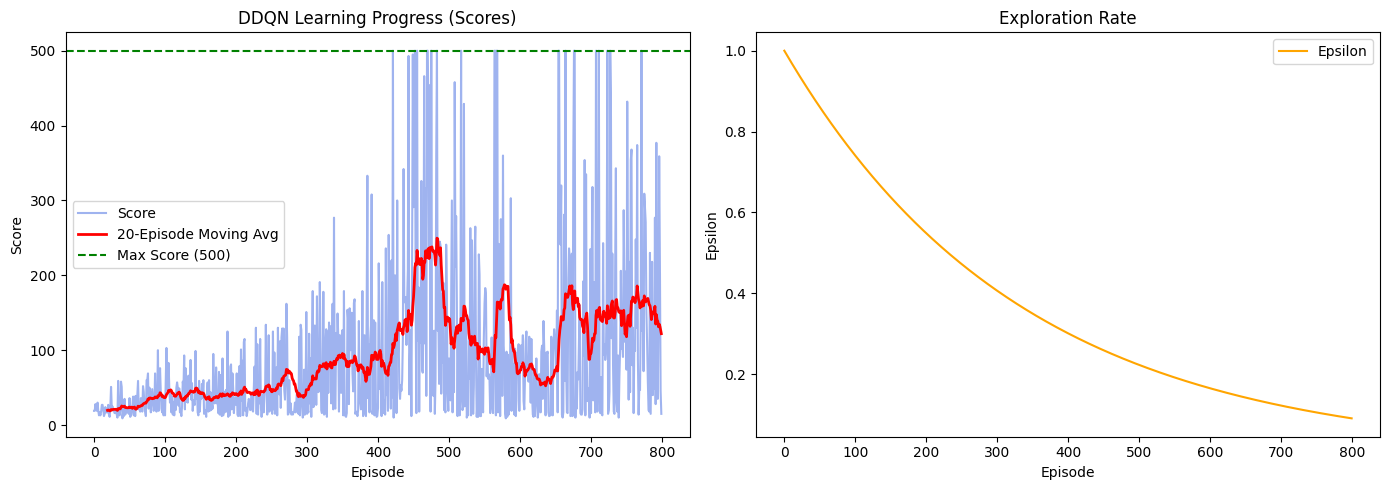

In [ ]:
# 1. 라이브러리 임포트
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque

# 2. 신경망 구조 정의 (상태 4개 -> 행동 2개)
class DQN(nn.Module):
    def __init__(self):
        super(DQN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(4, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.fc(x)

# 3. 하이퍼파라미터 설정
EPISODES = 800
GAMMA = 0.995
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY = 0.997
BATCH_SIZE = 64
MEMORY_SIZE = 10000
TAU = 0.005         # Soft Update 스며드는 비율

# 4. 에이전트 클래스 정의 (DDQN 및 Clipping 적용)
class Agent:
    def __init__(self):
        self.model = DQN()
        self.target_model = DQN()
        self.target_model.load_state_dict(self.model.state_dict())
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)
        self.memory = deque(maxlen=MEMORY_SIZE)
        self.epsilon = EPSILON_START

    def get_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, 1)
        state = torch.FloatTensor(state).unsqueeze(0)
        return self.model(state).argmax().item()

    def train(self):
        if len(self.memory) < BATCH_SIZE: return

        batch = random.sample(self.memory, BATCH_SIZE)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(np.array(states))
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards)
        next_states = torch.FloatTensor(np.array(next_states))
        dones = torch.FloatTensor(dones)

        # 현재 Q값
        current_q = self.model(states).gather(1, actions)

        # --- [✨ 핵심 1: Double DQN (DDQN) 적용] ---
        # 1. 현재 신경망(model)으로 다음 상태의 최적 '행동'을 선택
        best_actions = self.model(next_states).argmax(1).unsqueeze(1)
        # 2. 타겟 신경망(target_model)으로 그 행동의 '가치'를 평가 (과대적합 방지)
        next_q = self.target_model(next_states).gather(1, best_actions).squeeze(1).detach()
        # ------------------------------------------

        target_q = rewards + (GAMMA * next_q * (1 - dones))

        loss = nn.MSELoss()(current_q.squeeze(), target_q)

        self.optimizer.zero_grad()
        loss.backward()

        # --- [✨ 핵심 2: Gradient Clipping 적용] ---
        # 가중치가 한 번에 너무 크게 변형되어 기존 기억을 잃는 것(망각)을 방지
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        # ------------------------------------------

        self.optimizer.step()

# 5. 메인 학습 루프
env = gym.make('CartPole-v1')
agent = Agent()

score_history = []
epsilon_history = []

print("🚀 Double DQN 학습을 시작합니다! (총 800 에피소드)")

for e in range(EPISODES):
    state, _ = env.reset()
    score = 0

    while True:
        action = agent.get_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # --- [✨ 핵심 3: 직관적인 보상 체계로 롤백] ---
        # 복잡한 보상은 오히려 로컬 미니멈에 빠지게 하므로, 버티면 +1, 죽으면 -1로 단순화
        reward = 1.0
        if terminated:
            reward = -1.0

        agent.memory.append((state, action, reward, next_state, done))
        agent.train()

        # Soft Update (매 스텝마다 타겟망을 부드럽게 업데이트)
        for target_param, local_param in zip(agent.target_model.parameters(), agent.model.parameters()):
            target_param.data.copy_(TAU * local_param.data + (1.0 - TAU) * target_param.data)

        state = next_state
        score += 1

        if done:
            score_history.append(score)
            epsilon_history.append(agent.epsilon)

            if (e + 1) % 20 == 0:
                recent_mean = np.mean(score_history[-20:])
                print(f"에피소드: {e+1:3d}/{EPISODES} | 점수: {score:4d} | 최근 20판 평균: {recent_mean:5.1f} | 탐색률: {agent.epsilon:.3f}")
            break

    # 탐색률 감소
    agent.epsilon = max(EPSILON_END, agent.epsilon * EPSILON_DECAY)

print("🎉 학습 완료!")

# 6. 결과 시각화
plt.figure(figsize=(14, 5))

# 점수 그래프
plt.subplot(1, 2, 1)
plt.plot(score_history, color='royalblue', label='Score', alpha=0.5)
moving_avg = np.convolve(score_history, np.ones(20)/20, mode='valid') # 추세를 더 부드럽게 보기 위해 20판 평균으로 변경
plt.plot(range(19, len(score_history)), moving_avg, color='red', label='20-Episode Moving Avg', linewidth=2)
plt.axhline(y=500, color='green', linestyle='--', label='Max Score (500)')
plt.title('DDQN Learning Progress (Scores)')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.legend()

# 탐색률 그래프
plt.subplot(1, 2, 2)
plt.plot(epsilon_history, color='orange', label='Epsilon')
plt.title('Exploration Rate')
plt.xlabel('Episode')
plt.ylabel('Epsilon')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt
import numpy as np

# 1. 하이퍼파라미터 설정
LEARNING_RATE = 0.002
GAMMA         = 0.98
LMBDA         = 0.95   # GAE (가치 평가를 부드럽게 해주는 파라미터)
EPS_CLIP      = 0.2    # 핵심! 기존 지식에서 20% 이상 벗어나지 못하게 클리핑
K_EPOCHS      = 3      # 모은 데이터로 몇 번 반복 학습할 것인가
EPISODES      = 600

# 2. PPO 신경망 구조 (Actor-Critic 통합형)
class PPO(nn.Module):
    def __init__(self):
        super(PPO, self).__init__()
        self.data = []

        # 공통 신경망
        self.fc1   = nn.Linear(4, 64)

        # Actor (행동 확률 출력)
        self.fc_pi = nn.Linear(64, 2)
        # Critic (현재 상태의 가치 출력)
        self.fc_v  = nn.Linear(64, 1)

        self.optimizer = optim.Adam(self.parameters(), lr=LEARNING_RATE)

    # Actor: 확률 분포 계산
    def pi(self, x, softmax_dim=0):
        x = F.relu(self.fc1(x))
        x = self.fc_pi(x)
        prob = F.softmax(x, dim=softmax_dim)
        return prob

    # Critic: 가치 평가 계산
    def v(self, x):
        x = F.relu(self.fc1(x))
        v = self.fc_v(x)
        return v

    # 에피소드 동안의 경험 저장
    def put_data(self, transition):
        self.data.append(transition)

    # 저장된 데이터를 텐서로 변환
    def make_batch(self):
        s_lst, a_lst, r_lst, s_prime_lst, prob_a_lst, done_lst = [], [], [], [], [], []
        for transition in self.data:
            s, a, r, s_prime, prob_a, done = transition
            s_lst.append(s)
            a_lst.append([a])
            r_lst.append([r])
            s_prime_lst.append(s_prime)
            prob_a_lst.append([prob_a])
            done_mask = 0 if done else 1
            done_lst.append([done_mask])

        s = torch.tensor(np.array(s_lst), dtype=torch.float)
        a = torch.tensor(a_lst)
        r = torch.tensor(r_lst)
        s_prime = torch.tensor(np.array(s_prime_lst), dtype=torch.float)
        done_mask = torch.tensor(done_lst, dtype=torch.float)
        prob_a = torch.tensor(prob_a_lst)
        self.data = []
        return s, a, r, s_prime, done_mask, prob_a

    # PPO 핵심 학습 알고리즘
    def train_net(self):
        s, a, r, s_prime, done_mask, prob_a = self.make_batch()

        for i in range(K_EPOCHS):
            # TD Target 및 Advantage(유리함 정도) 계산
            td_target = r + GAMMA * self.v(s_prime) * done_mask
            delta = td_target - self.v(s)
            delta = delta.detach().numpy()

            advantage_lst = []
            advantage = 0.0
            for delta_t in delta[::-1]:
                advantage = GAMMA * LMBDA * advantage + delta_t[0]
                advantage_lst.append([advantage])
            advantage_lst.reverse()
            advantage = torch.tensor(advantage_lst, dtype=torch.float)

            # 새로운 신경망과 옛날 신경망의 행동 확률 비율 계산
            pi = self.pi(s, softmax_dim=1)
            pi_a = pi.gather(1, a)
            ratio = torch.exp(torch.log(pi_a) - torch.log(prob_a))

            # 클리핑(Clipping)을 통해 급격한 변화 방지
            surr1 = ratio * advantage
            surr2 = torch.clamp(ratio, 1-EPS_CLIP, 1+EPS_CLIP) * advantage

            # 최종 Loss = Actor Loss + Critic Loss
            loss = -torch.min(surr1, surr2) + F.smooth_l1_loss(self.v(s), td_target.detach())

            self.optimizer.zero_grad()
            loss.mean().backward()
            self.optimizer.step()

# 3. 메인 학습 루프
env = gym.make('CartPole-v1')
model = PPO()

score_history = []
print("🚀 PPO 알고리즘 학습을 시작합니다! (총 600 에피소드)")

for e in range(EPISODES):
    state, _ = env.reset()
    score = 0

    while True:
        # PPO는 무작위 탐험(Epsilon)이 아니라 확률에 따라 행동을 선택합니다.
        prob = model.pi(torch.from_numpy(state).float())
        m = Categorical(prob)
        action = m.sample().item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # PPO는 보상을 복잡하게 꼬지 않아도 알아서 잘 배웁니다 (순수 점수 그대로 사용)
        model.put_data((state, action, reward, next_state, prob[action].item(), done))

        state = next_state
        score += reward

        if done:
            break

    # 한 에피소드가 끝날 때마다 모인 데이터로 뇌를 업데이트 합니다 (On-Policy)
    model.train_net()
    score_history.append(score)

    if (e + 1) % 20 == 0:
        recent_mean = np.mean(score_history[-20:])
        print(f"에피소드: {e+1:3d}/{EPISODES} | 점수: {score:4.0f} | 최근 20판 평균: {recent_mean:5.1f}")

print("🎉 PPO 학습 완료!")

# 4. 결과 시각화
plt.figure(figsize=(10, 5))
plt.plot(score_history, color='royalblue', label='Score', alpha=0.5)
moving_avg = np.convolve(score_history, np.ones(20)/20, mode='valid')
plt.plot(range(19, len(score_history)), moving_avg, color='red', label='20-Episode Moving Avg', linewidth=2)
plt.axhline(y=500, color='green', linestyle='--', label='Max Score (500)')
plt.title('PPO Learning Progress (Scores)')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

🚀 MSE 기반 DQN 학습 시작!
에피소드:  20/500 | 점수:   17 | 최근 20판 평균:  20.8
에피소드:  40/500 | 점수:   17 | 최근 20판 평균:  27.7
에피소드:  60/500 | 점수:   55 | 최근 20판 평균:  41.8
에피소드:  80/500 | 점수:   64 | 최근 20판 평균:  47.0
에피소드: 100/500 | 점수:   20 | 최근 20판 평균:  44.8
에피소드: 120/500 | 점수:  115 | 최근 20판 평균:  76.2
에피소드: 140/500 | 점수:  248 | 최근 20판 평균:  85.5
에피소드: 160/500 | 점수:  157 | 최근 20판 평균: 118.5
에피소드: 180/500 | 점수:   99 | 최근 20판 평균: 106.6
에피소드: 200/500 | 점수:  142 | 최근 20판 평균:  91.4
에피소드: 220/500 | 점수:  121 | 최근 20판 평균:  99.2
에피소드: 240/500 | 점수:   37 | 최근 20판 평균:  96.8
에피소드: 260/500 | 점수:  220 | 최근 20판 평균: 108.2
에피소드: 280/500 | 점수:  169 | 최근 20판 평균: 149.8
에피소드: 300/500 | 점수:  191 | 최근 20판 평균: 152.8
에피소드: 320/500 | 점수:  215 | 최근 20판 평균: 147.3
에피소드: 340/500 | 점수:   61 | 최근 20판 평균: 171.9
에피소드: 360/500 | 점수:   65 | 최근 20판 평균: 277.5
에피소드: 380/500 | 점수:  143 | 최근 20판 평균: 294.9
에피소드: 400/500 | 점수:  148 | 최근 20판 평균: 231.3
에피소드: 420/500 | 점수:  156 | 최근 20판 평균: 190.9
에피소드: 440/500 | 점수:  206 | 최근 20판 평균: 265.1
에피소드: 460/50

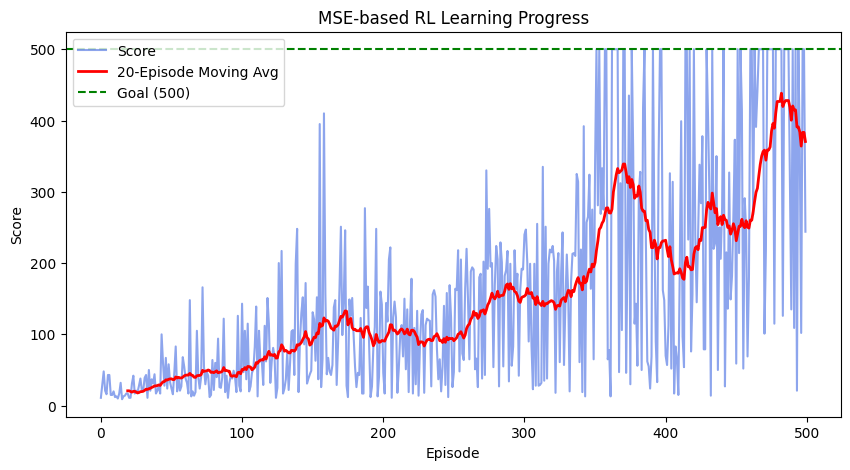

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque

# 1. 하이퍼파라미터
EPISODES = 500
GAMMA = 0.99
BATCH_SIZE = 64
LR = 0.001
EPSILON_DECAY = 0.995
EPSILON_MIN = 0.01

# 2. Q-네트워크 (가치 예측망)
class DQN(nn.Module):
    def __init__(self):
        super(DQN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 2) # 왼쪽(0), 오른쪽(1)의 예상 가치 출력
        )

    def forward(self, x):
        return self.fc(x)

# 3. 에이전트 (MSE 학습 로직 포함)
class Agent:
    def __init__(self):
        self.model = DQN()
        self.target_model = DQN()
        self.target_model.load_state_dict(self.model.state_dict())
        self.optimizer = optim.Adam(self.model.parameters(), lr=LR)
        self.memory = deque(maxlen=10000)
        self.epsilon = 1.0

    def get_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, 1)
        state = torch.FloatTensor(state).unsqueeze(0)
        return self.model(state).argmax().item()

    def train(self):
        if len(self.memory) < BATCH_SIZE: return

        batch = random.sample(self.memory, BATCH_SIZE)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(np.array(states))
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards)
        next_states = torch.FloatTensor(np.array(next_states))
        dones = torch.FloatTensor(dones)

        # 🎯 [핵심] 예측값: 현재 상태에서 AI가 예상한 점수
        current_q = self.model(states).gather(1, actions).squeeze()

        # 🎯 [핵심] 목표값: 실제 받은 보상 + 미래의 예상 점수
        next_q = self.target_model(next_states).max(1)[0].detach()
        target_q = rewards + (GAMMA * next_q * (1 - dones))

        # 📊 [MSE 통계방식 적용] 예측값과 목표값의 평균 제곱 오차 계산
        # 이 오차(Loss)가 0에 가까워질수록 AI는 완벽한 예측을 하게 됩니다.
        loss = nn.MSELoss()(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

# 4. 메인 학습 루프
env = gym.make('CartPole-v1')
agent = Agent()
score_history = []

print("🚀 MSE 기반 DQN 학습 시작!")

for e in range(EPISODES):
    state, _ = env.reset()
    score = 0

    while True:
        action = agent.get_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # 보상 체계: 쓰러지면 -1점, 버티면 1점
        reward = 1.0 if not terminated else -1.0

        agent.memory.append((state, action, reward, next_state, done))
        agent.train()

        # 타겟 모델 업데이트 (소프트 업데이트 방식)
        tau = 0.005
        for target_param, local_param in zip(agent.target_model.parameters(), agent.model.parameters()):
            target_param.data.copy_(tau * local_param.data + (1.0 - tau) * target_param.data)

        state = next_state
        score += 1

        if done:
            score_history.append(score)
            if (e + 1) % 20 == 0:
                print(f"에피소드: {e+1:3d}/{EPISODES} | 점수: {score:4d} | 최근 20판 평균: {np.mean(score_history[-20:]):5.1f}")
            break

    # 탐색률 감소
    agent.epsilon = max(EPSILON_MIN, agent.epsilon * EPSILON_DECAY)

print("🎉 학습 완료!")

# 5. 결과 시각화
plt.figure(figsize=(10, 5))
plt.plot(score_history, label='Score', color='royalblue', alpha=0.6)
moving_avg = np.convolve(score_history, np.ones(20)/20, mode='valid')
plt.plot(range(19, len(score_history)), moving_avg, color='red', label='20-Episode Moving Avg', linewidth=2)
plt.axhline(y=500, color='green', linestyle='--', label='Goal (500)')
plt.title('MSE-based RL Learning Progress')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.legend()
plt.show()

In [ ]:
import torch

# 학습된 Q-네트워크의 가중치(state_dict)를 파일로 저장
torch.save(agent.model.state_dict(), 'cartpole_dqn.pth')

print("✅ 모델 저장 완료! 왼쪽 폴더 아이콘을 눌러 파일을 확인하세요.")

✅ 모델 저장 완료! 왼쪽 폴더 아이콘을 눌러 파일을 확인하세요.


🚀 학습 시작! (점수와 Loss를 함께 기록합니다)
에피소드:  20/500 | 점수:   12 | 평균점수:  22.8 | 평균Loss: 0.4673
에피소드:  40/500 | 점수:   22 | 평균점수:  25.2 | 평균Loss: 0.3287
에피소드:  60/500 | 점수:   61 | 평균점수:  27.6 | 평균Loss: 0.3492
에피소드:  80/500 | 점수:   82 | 평균점수:  47.3 | 평균Loss: 0.4580
에피소드: 100/500 | 점수:   69 | 평균점수:  74.0 | 평균Loss: 0.9647
에피소드: 120/500 | 점수:   64 | 평균점수:  70.5 | 평균Loss: 1.2583
에피소드: 140/500 | 점수:   58 | 평균점수:  94.8 | 평균Loss: 1.4744
에피소드: 160/500 | 점수:   82 | 평균점수: 103.3 | 평균Loss: 2.2109
에피소드: 180/500 | 점수:  118 | 평균점수:  63.0 | 평균Loss: 2.2549
에피소드: 200/500 | 점수:   18 | 평균점수:  56.5 | 평균Loss: 4.4180
에피소드: 220/500 | 점수:   52 | 평균점수:  76.8 | 평균Loss: 3.9959
에피소드: 240/500 | 점수:  183 | 평균점수:  61.3 | 평균Loss: 5.0379
에피소드: 260/500 | 점수:   34 | 평균점수:  84.8 | 평균Loss: 4.6211
에피소드: 280/500 | 점수:   40 | 평균점수:  73.2 | 평균Loss: 6.9812
에피소드: 300/500 | 점수:   53 | 평균점수:  82.8 | 평균Loss: 6.3245
에피소드: 320/500 | 점수:   37 | 평균점수: 111.8 | 평균Loss: 7.1758
에피소드: 340/500 | 점수:  120 | 평균점수:  95.6 | 평균Loss: 7.4520
에피소드: 360/500 | 점수

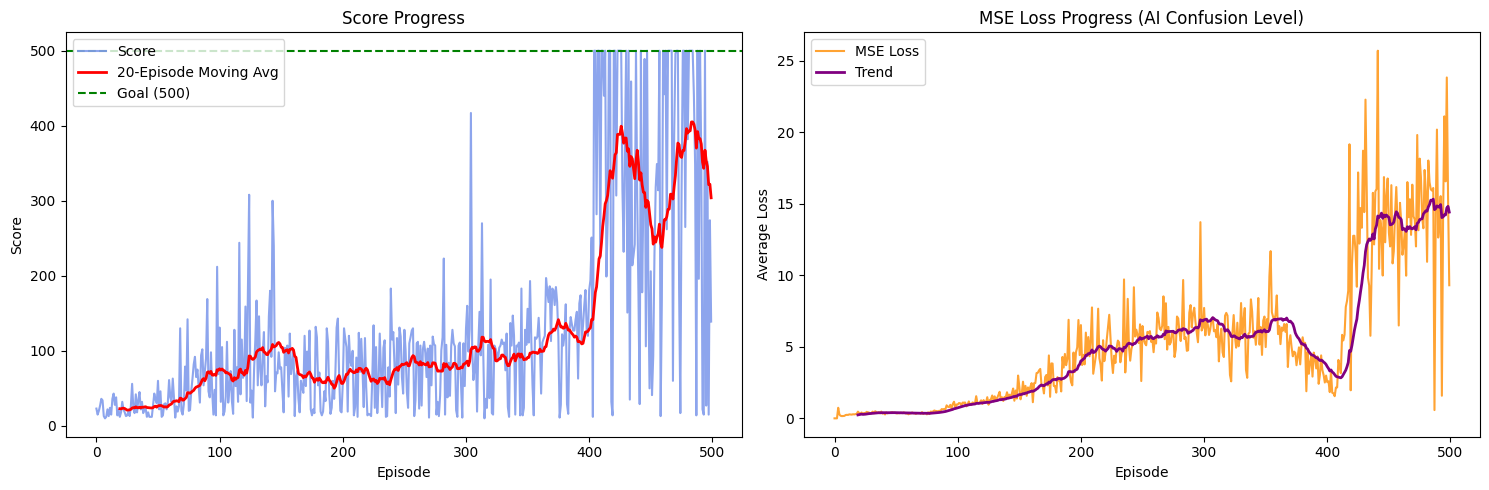

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque

# 1. 하이퍼파라미터
EPISODES = 500
GAMMA = 0.99
BATCH_SIZE = 64
LR = 0.001
EPSILON_DECAY = 0.995
EPSILON_MIN = 0.01

# 2. Q-네트워크
class DQN(nn.Module):
    def __init__(self):
        super(DQN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.fc(x)

# 3. 에이전트
class Agent:
    def __init__(self):
        self.model = DQN()
        self.target_model = DQN()
        self.target_model.load_state_dict(self.model.state_dict())
        self.optimizer = optim.Adam(self.model.parameters(), lr=LR)
        self.memory = deque(maxlen=10000)
        self.epsilon = 1.0

    def get_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, 1)
        state = torch.FloatTensor(state).unsqueeze(0)
        return self.model(state).argmax().item()

    def train(self):
        # 메모리가 덜 찼으면 학습하지 않고 Loss 0 반환
        if len(self.memory) < BATCH_SIZE: return 0.0

        batch = random.sample(self.memory, BATCH_SIZE)
        states, actions, rewards, next_states, dones = zip(*batch)

        states = torch.FloatTensor(np.array(states))
        actions = torch.LongTensor(actions).unsqueeze(1)
        rewards = torch.FloatTensor(rewards)
        next_states = torch.FloatTensor(np.array(next_states))
        dones = torch.FloatTensor(dones)

        current_q = self.model(states).gather(1, actions).squeeze()
        next_q = self.target_model(next_states).max(1)[0].detach()
        target_q = rewards + (GAMMA * next_q * (1 - dones))

        loss = nn.MSELoss()(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # 🎯 [추가된 부분] 계산된 오차(Loss) 값을 파이썬 숫자로 변환하여 반환
        return loss.item()

# 4. 메인 학습 루프
env = gym.make('CartPole-v1')
agent = Agent()

score_history = []
loss_history = []  # 🎯 [추가된 부분] Loss 기록용 리스트

print("🚀 학습 시작! (점수와 Loss를 함께 기록합니다)")

for e in range(EPISODES):
    state, _ = env.reset()
    score = 0
    episode_loss = 0 # 이번 에피소드의 누적 Loss
    train_steps = 0  # 이번 에피소드에서 학습한 횟수

    while True:
        action = agent.get_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        reward = 1.0 if not terminated else -1.0

        agent.memory.append((state, action, reward, next_state, done))

        # 🎯 [추가된 부분] 훈련할 때마다 뱉어내는 Loss 값을 누적시킴
        step_loss = agent.train()
        if step_loss > 0:
            episode_loss += step_loss
            train_steps += 1

        tau = 0.005
        for target_param, local_param in zip(agent.target_model.parameters(), agent.model.parameters()):
            target_param.data.copy_(tau * local_param.data + (1.0 - tau) * target_param.data)

        state = next_state
        score += 1

        if done:
            score_history.append(score)

            # 🎯 [추가된 부분] 에피소드 평균 Loss 기록
            avg_loss = (episode_loss / train_steps) if train_steps > 0 else 0
            loss_history.append(avg_loss)

            if (e + 1) % 20 == 0:
                print(f"에피소드: {e+1:3d}/{EPISODES} | 점수: {score:4d} | 평균점수: {np.mean(score_history[-20:]):5.1f} | 평균Loss: {avg_loss:.4f}")
            break

    agent.epsilon = max(EPSILON_MIN, agent.epsilon * EPSILON_DECAY)

print("🎉 학습 완료!")

# 5. 결과 시각화 (그래프 2개 나란히 출력)
plt.figure(figsize=(15, 5))

# [첫 번째 그래프: 점수]
plt.subplot(1, 2, 1)
plt.plot(score_history, label='Score', color='royalblue', alpha=0.6)
moving_avg = np.convolve(score_history, np.ones(20)/20, mode='valid')
plt.plot(range(19, len(score_history)), moving_avg, color='red', label='20-Episode Moving Avg', linewidth=2)
plt.axhline(y=500, color='green', linestyle='--', label='Goal (500)')
plt.title('Score Progress')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.legend()

# [두 번째 그래프: 예측 오차(Loss)]
plt.subplot(1, 2, 2)
plt.plot(loss_history, label='MSE Loss', color='darkorange', alpha=0.8)
# 추세를 보기 쉽게 Loss도 이동평균선을 그려줍니다.
loss_moving_avg = np.convolve(loss_history, np.ones(20)/20, mode='valid')
plt.plot(range(19, len(loss_history)), loss_moving_avg, color='purple', label='Trend', linewidth=2)
plt.title('MSE Loss Progress (AI Confusion Level)')
plt.xlabel('Episode')
plt.ylabel('Average Loss')
plt.legend()

plt.tight_layout()
plt.show()